# Практическая 14 (Саттаров Булат Рамилевич ЭФМО-01-25)

## Задание

Практика по композициям алгоритмов и случайному лесу в задаче кредитного скоринга.

Необходимо:

1. Загрузить данные `credit_scoring_train.csv` и `credit_scoring_test.csv`.
2. Заполнить пропуски медианными значениями.
3. Обучить дерево решений `DecisionTreeClassifier` максимальной глубины 3, `random_state=17`.
4. Сделать прогноз для тестовой выборки и сохранить результат.
5. Предсказывать вероятности дефолта для клиентов тестовой выборки.
6. Настроить дерево решений с помощью `GridSearchCV`.
7. Обучить случайный лес, настроить параметры и сравнить результат.
8. Посмотреть важность признаков и сформировать финальный прогноз.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report, roc_curve

In [2]:
SEED = 17

## Загрузка данных

В обучающей выборке целевой признак — `Delinquent90`, то есть факт просрочки платежа более 90 дней.

In [3]:
train_df = pd.read_csv('credit_scoring_train.csv', index_col='client_id')
test_df = pd.read_csv('credit_scoring_test.csv', index_col='client_id')

train_df.head()

,DIR,Age,NumLoans,NumRealEstateLoans,NumDependents,Num30-59Delinquencies,Num60-89Delinquencies,Income,BalanceToCreditLimit,Delinquent90
client_id,,,,,,,,,,
0,0.496289,49.1,13,0,0.0,2,0,5298.360639,0.387028,0
1,0.433567,48.0,9,2,2.0,1,0,6008.056256,0.234679,0
2,2206.731199,55.5,21,1,NaN,1,0,NaN,0.348227,0
3,886.132793,55.3,3,0,0.0,0,0,NaN,0.971930,0
4,0.000000,52.3,1,0,0.0,0,0,2504.613105,1.004350,0


In [4]:
print('Train:', train_df.shape)
print('Test:', test_df.shape)
train_df.info()

Train: (75000, 10)
Test: (75000, 9)
<class 'pandas.core.frame.DataFrame'>
Index: 75000 entries, 0 to 74999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   DIR                    75000 non-null  float64
 1   Age                    75000 non-null  float64
 2   NumLoans               75000 non-null  int64  
 3   NumRealEstateLoans     75000 non-null  int64  
 4   NumDependents          73084 non-null  float64
 5   Num30-59Delinquencies  75000 non-null  int64  
 6   Num60-89Delinquencies  75000 non-null  int64  
 7   Income                 60153 non-null  float64
 8   BalanceToCreditLimit   75000 non-null  float64
 9   Delinquent90           75000 non-null  int64  
dtypes: float64(5), int64(5)
memory usage: 6.3 MB


In [5]:
train_df.describe()

,DIR,Age,NumLoans,NumRealEstateLoans,NumDependents,Num30-59Delinquencies,Num60-89Delinquencies,Income,BalanceToCreditLimit,Delinquent90
count,75000.000000,75000.000000,75000.00000,75000.000000,73084.000000,75000.000000,75000.000000,6.015300e+04,75000.000000,75000.000000
mean,353.260293,52.595605,8.44976,1.016693,0.755966,0.428320,0.248000,6.740059e+03,6.276196,0.066840
std,2117.237432,14.869729,5.15644,1.124019,1.108119,4.276439,4.239486,1.422875e+04,267.743321,0.249746
min,0.000000,21.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,0.176022,41.300000,5.00000,0.000000,0.000000,0.000000,0.000000,3.421354e+03,0.029703,0.000000
50%,0.366848,52.200000,8.00000,1.000000,0.000000,0.000000,0.000000,5.424552e+03,0.153720,0.000000
75%,0.862650,63.100000,11.00000,2.000000,1.000000,0.000000,0.000000,8.291518e+03,0.560638,0.000000
max,332600.272820,109.800000,56.00000,32.000000,20.000000,98.000000,98.000000,1.805573e+06,50873.874533,1.000000


## Анализ целевого признака и пропусков

Задача является бинарной классификацией. Доля клиентов с просрочкой сильно меньше доли клиентов без просрочки, поэтому основной метрикой будет `ROC AUC`, а не только `accuracy`.

In [6]:
y = train_df['Delinquent90'].copy()
X = train_df.drop(columns=['Delinquent90']).copy()
X_test = test_df.copy()

print('Распределение целевого признака:')
print(y.value_counts(normalize=True).rename('share'))
print('\nПропуски в train:')
print(X.isna().sum())
print('\nПропуски в test:')
print(X_test.isna().sum())

Распределение целевого признака:
Delinquent90
0    0.93316
1    0.06684
Name: share, dtype: float64

Пропуски в train:
DIR                          0
Age                          0
NumLoans                     0
NumRealEstateLoans           0
NumDependents             1916
Num30-59Delinquencies        0
Num60-89Delinquencies        0
Income                   14847
BalanceToCreditLimit         0
dtype: int64

Пропуски в test:
DIR                          0
Age                          0
NumLoans                     0
NumRealEstateLoans           0
NumDependents             2008
Num30-59Delinquencies        0
Num60-89Delinquencies        0
Income                   14884
BalanceToCreditLimit         0
dtype: int64


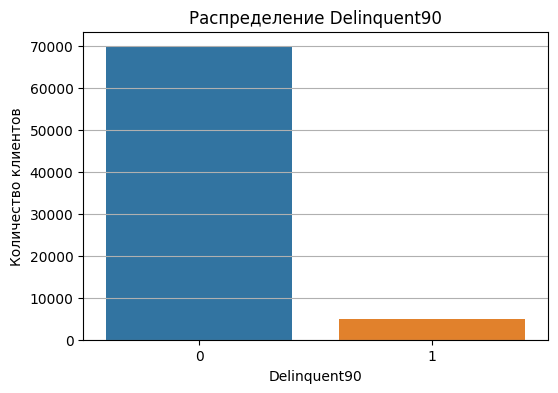

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y, hue=y, palette='tab10', legend=False)
plt.title('Распределение Delinquent90')
plt.xlabel('Delinquent90')
plt.ylabel('Количество клиентов')
plt.grid(axis='y')
plt.show()

## Подготовка данных

По условию заполним пропуски медианными значениями. Медианы считаются по обучающей выборке и затем применяются к тестовой.

In [8]:
medians = X.median()
X = X.fillna(medians)
X_test = X_test.fillna(medians)

print('Пропуски после заполнения:')
print('train:', int(X.isna().sum().sum()))
print('test:', int(X_test.isna().sum().sum()))

Пропуски после заполнения:
train: 0
test: 0


In [9]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

X_train.shape, X_valid.shape

((56250, 9), (18750, 9))

## Функция для сохранения прогнозов

Для отправки результата используется CSV с индексом `client_id` и столбцом `Delinquent90`.

In [10]:
def write_to_submission_file(predicted_labels, out_file, target='Delinquent90', index_label='client_id'):
    predicted_df = pd.DataFrame(
        predicted_labels,
        index=X_test.index,
        columns=[target]
    )
    predicted_df.to_csv(out_file, index_label=index_label)

## 1. Дерево решений без настройки параметров

Обучим дерево максимальной глубины 3.

In [11]:
first_tree = DecisionTreeClassifier(max_depth=3, random_state=SEED)
first_tree.fit(X_train, y_train)

valid_pred_tree = first_tree.predict(X_valid)
valid_proba_tree = first_tree.predict_proba(X_valid)[:, 1]

print('Accuracy:', round(accuracy_score(y_valid, valid_pred_tree), 4))
print('ROC AUC:', round(roc_auc_score(y_valid, valid_proba_tree), 4))
print()
print(classification_report(y_valid, valid_pred_tree))

Accuracy: 0.9324
ROC AUC: 0.7896

              precision    recall  f1-score   support

           0       0.94      1.00      0.96     17497
           1       0.45      0.06      0.10      1253

    accuracy                           0.93     18750
   macro avg       0.70      0.53      0.53     18750
weighted avg       0.90      0.93      0.91     18750



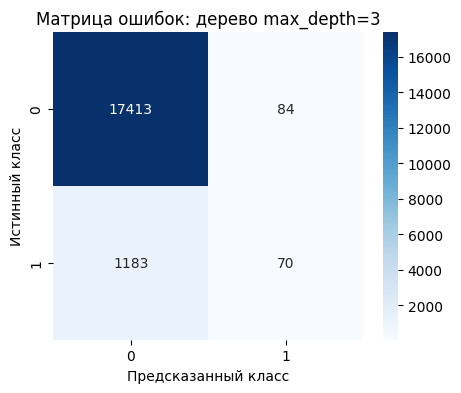

In [12]:
matrix = confusion_matrix(y_valid, valid_pred_tree)
plt.figure(figsize=(5, 4))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок: дерево max_depth=3')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

In [13]:
first_tree.fit(X, y)
first_tree_pred = first_tree.predict(X_test)
first_tree_pred_probs = first_tree.predict_proba(X_test)[:, 1]

write_to_submission_file(first_tree_pred, 'credit_scoring_first_tree.csv')
write_to_submission_file(first_tree_pred_probs, 'credit_scoring_first_tree_proba.csv')

print('Сохранены файлы:')
print('credit_scoring_first_tree.csv')
print('credit_scoring_first_tree_proba.csv')

Сохранены файлы:
credit_scoring_first_tree.csv
credit_scoring_first_tree_proba.csv


## 2. Дерево решений с настройкой параметров

Подберем `max_depth` и `min_samples_leaf` по ROC AUC. Используем стратифицированную кросс-валидацию, так как классы несбалансированы.

In [14]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

tree_params = {
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [10, 50]
}

locally_best_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    tree_params,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)
locally_best_tree.fit(X_train, y_train)

print('Лучшие параметры:', locally_best_tree.best_params_)
print('Лучший CV ROC AUC:', round(locally_best_tree.best_score_, 4))

Лучшие параметры: {'max_depth': 7, 'min_samples_leaf': 50}
Лучший CV ROC AUC: 0.8305


In [15]:
tuned_tree = locally_best_tree.best_estimator_
valid_proba_tuned_tree = tuned_tree.predict_proba(X_valid)[:, 1]
valid_pred_tuned_tree = tuned_tree.predict(X_valid)

print('Accuracy:', round(accuracy_score(y_valid, valid_pred_tuned_tree), 4))
print('ROC AUC:', round(roc_auc_score(y_valid, valid_proba_tuned_tree), 4))
print()
print(classification_report(y_valid, valid_pred_tuned_tree))

Accuracy: 0.933
ROC AUC: 0.8323

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     17497
           1       0.49      0.11      0.18      1253

    accuracy                           0.93     18750
   macro avg       0.72      0.55      0.57     18750
weighted avg       0.91      0.93      0.91     18750



In [16]:
locally_best_tree.fit(X, y)
tuned_tree_pred_probs = locally_best_tree.predict_proba(X_test)[:, 1]
write_to_submission_file(tuned_tree_pred_probs, 'credit_scoring_tuned_tree.csv')
print('Сохранен файл: credit_scoring_tuned_tree.csv')

Сохранен файл: credit_scoring_tuned_tree.csv


## 3. Случайный лес без настройки параметров

Теперь обучим `RandomForestClassifier`. Случайный лес обычно дает более устойчивый результат, чем одно дерево.

In [17]:
first_forest = RandomForestClassifier(
    n_estimators=80,
    random_state=SEED,
    n_jobs=-1,
    class_weight='balanced_subsample'
)
first_forest.fit(X_train, y_train)

valid_pred_forest = first_forest.predict(X_valid)
valid_proba_forest = first_forest.predict_proba(X_valid)[:, 1]

print('Accuracy:', round(accuracy_score(y_valid, valid_pred_forest), 4))
print('ROC AUC:', round(roc_auc_score(y_valid, valid_proba_forest), 4))
print()
print(classification_report(y_valid, valid_pred_forest))

Accuracy: 0.9331
ROC AUC: 0.8153

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     17497
           1       0.50      0.09      0.15      1253

    accuracy                           0.93     18750
   macro avg       0.72      0.54      0.56     18750
weighted avg       0.91      0.93      0.91     18750



In [18]:
first_forest.fit(X, y)
first_forest_pred = first_forest.predict_proba(X_test)[:, 1]
write_to_submission_file(first_forest_pred, 'credit_scoring_first_forest.csv')
print('Сохранен файл: credit_scoring_first_forest.csv')

Сохранен файл: credit_scoring_first_forest.csv


## 4. Настройка случайного леса

Полный перебор параметров на такой выборке может быть долгим, поэтому возьмем компактную сетку. Основная цель — сравнить результат с деревом решений и получить финальный прогноз.

In [19]:
forest_params = {
    'max_features': [0.5, 1.0],
    'min_samples_leaf': [5, 20]
}

locally_best_forest = GridSearchCV(
    RandomForestClassifier(
        n_estimators=60,
        random_state=SEED,
        n_jobs=-1,
        class_weight='balanced_subsample'
    ),
    forest_params,
    cv=2,
    scoring='roc_auc',
    n_jobs=-1
)
locally_best_forest.fit(X_train, y_train)

print('Лучшие параметры:', locally_best_forest.best_params_)
print('Лучший CV ROC AUC:', round(locally_best_forest.best_score_, 4))

Лучшие параметры: {'max_features': 0.5, 'min_samples_leaf': 20}
Лучший CV ROC AUC: 0.8401


In [20]:
tuned_forest = locally_best_forest.best_estimator_
valid_proba_tuned_forest = tuned_forest.predict_proba(X_valid)[:, 1]
valid_pred_tuned_forest = tuned_forest.predict(X_valid)

print('Accuracy:', round(accuracy_score(y_valid, valid_pred_tuned_forest), 4))
print('ROC AUC:', round(roc_auc_score(y_valid, valid_proba_tuned_forest), 4))
print()
print(classification_report(y_valid, valid_pred_tuned_forest))

Accuracy: 0.8605
ROC AUC: 0.8385

              precision    recall  f1-score   support

           0       0.97      0.88      0.92     17497
           1       0.26      0.61      0.37      1253

    accuracy                           0.86     18750
   macro avg       0.62      0.74      0.64     18750
weighted avg       0.92      0.86      0.88     18750



## Сравнение моделей

In [21]:
comparison = pd.DataFrame({
    'Модель': ['DecisionTree max_depth=3', 'DecisionTree tuned', 'RandomForest', 'RandomForest tuned'],
    'Accuracy': [
        accuracy_score(y_valid, valid_pred_tree),
        accuracy_score(y_valid, valid_pred_tuned_tree),
        accuracy_score(y_valid, valid_pred_forest),
        accuracy_score(y_valid, valid_pred_tuned_forest)
    ],
    'ROC AUC': [
        roc_auc_score(y_valid, valid_proba_tree),
        roc_auc_score(y_valid, valid_proba_tuned_tree),
        roc_auc_score(y_valid, valid_proba_forest),
        roc_auc_score(y_valid, valid_proba_tuned_forest)
    ]
})
comparison

,Модель,Accuracy,ROC AUC
0,DecisionTree max_depth=3,0.932427,0.789600
1,DecisionTree tuned,0.932960,0.832282
2,RandomForest,0.933120,0.815299
3,RandomForest tuned,0.860533,0.838541


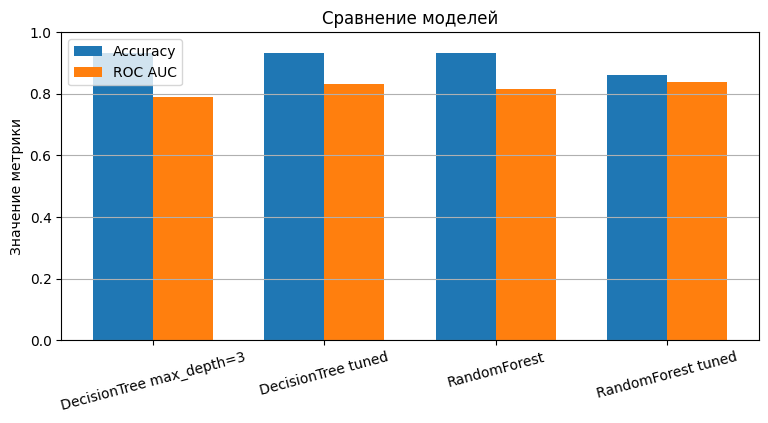

In [22]:
plt.figure(figsize=(9, 4))
x = np.arange(len(comparison['Модель']))
width = 0.35
plt.bar(x - width/2, comparison['Accuracy'], width, label='Accuracy')
plt.bar(x + width/2, comparison['ROC AUC'], width, label='ROC AUC')
plt.xticks(x, comparison['Модель'], rotation=15)
plt.ylim(0, 1)
plt.ylabel('Значение метрики')
plt.title('Сравнение моделей')
plt.legend()
plt.grid(axis='y')
plt.show()

## Важность признаков

Посмотрим, какие признаки случайный лес считает наиболее важными.

In [23]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': tuned_forest.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance

,feature,importance
8,BalanceToCreditLimit,0.369926
5,Num30-59Delinquencies,0.158931
1,Age,0.113431
0,DIR,0.094368
6,Num60-89Delinquencies,0.088619
7,Income,0.082723
2,NumLoans,0.054436
3,NumRealEstateLoans,0.020840
4,NumDependents,0.016726


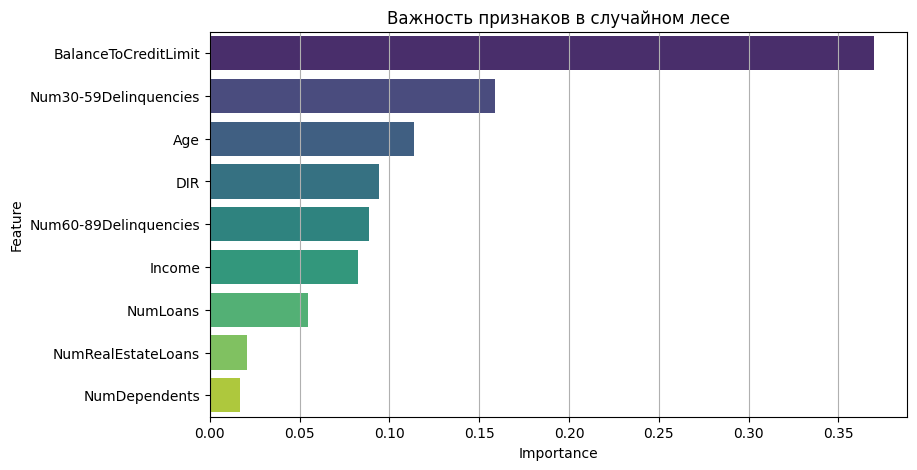

In [24]:
plt.figure(figsize=(9, 5))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Важность признаков в случайном лесе')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x')
plt.show()

## Финальный прогноз

Для финального файла обучим случайный лес с найденными параметрами на всей обучающей выборке и сохраним вероятности дефолта.

In [25]:
final_forest = RandomForestClassifier(
    n_estimators=120,
    random_state=SEED,
    n_jobs=-1,
    class_weight='balanced_subsample',
    **locally_best_forest.best_params_
)
final_forest.fit(X, y)
final_forest_pred = final_forest.predict_proba(X_test)[:, 1]
write_to_submission_file(final_forest_pred, 'credit_scoring_final_forest.csv')

print('Сохранен файл: credit_scoring_final_forest.csv')
print(pd.Series(final_forest_pred).describe())

Сохранен файл: credit_scoring_final_forest.csv
count    75000.000000
mean         0.237294
std          0.238046
min          0.000000
25%          0.058739
50%          0.144699
75%          0.341463
max          0.982154
dtype: float64


## Вывод

В практической работе была решена задача кредитного скоринга. Данные были загружены, пропуски в признаках `Income` и `NumDependents` заполнены медианными значениями.

Сначала было обучено дерево решений максимальной глубины 3. Затем дерево было настроено с помощью `GridSearchCV`. После этого были обучены случайный лес без настройки и случайный лес с подбором параметров. Для сравнения использовались `Accuracy` и `ROC AUC`, при этом основной метрикой выбрана `ROC AUC`, потому что классы несбалансированы.

Случайный лес показал более устойчивое качество по сравнению с одиночным деревом. Также была построена таблица важности признаков. Финальный прогноз вероятностей дефолта сохранен в файл `credit_scoring_final_forest.csv`.